# ENGR 1451/2451 — Weekly Assignment 2
**10 points**

This assignment applies the descriptive-statistics and visual-exploration methods introduced in the W02A lab notebooks: center and spread, quartiles and outliers, histograms and boxplots, grouped summaries, and the importance of pairing numerical summaries with visualizations.


 **Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

Put `iris.csv` in a folder named `data` next to this notebook so that the path below works.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

iris = pd.read_csv(Path("./data/iris.csv"))
iris.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## LE2-1. Shifting and scaling data (2 pts)

Consider the following measurements:

\[
x = [4,\ 6,\ 8,\ 10,\ 12].
\]

Create two transformed versions:

- **shifted:** \(x + 7\)
- **scaled:** \(3x\)

### A. Predict first (1 pt)

Without calculating, predict what happens to the **mean**, **median**, **sample standard deviation**, and **IQR** after each transformation.

Complete the table in words such as *increases by 7*, *unchanged*, or *multiplied by 3*.

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | Increase by 7 | Scale by 3 |
| Median | Increase by 7 | Scale by 3 |
| Sample standard deviation | No change | Scale by 3 |
| IQR | No change | Scale by 3 |


**Answer:**

### B. Verify with Python (1.5 pts)

Create a small summary table for the original, shifted, and scaled data containing:

- mean;
- median;
- sample standard deviation; and
- IQR.

Then state whether the results agree with your predictions.



In [2]:
x = pd.Series([4, 6, 8, 10, 12], name="original")
shifted = x + 7
scaled = 3 * x

# Your code here
mean_initial = x.mean()
mean_shifted = shifted.mean()
mean_scaled = scaled.mean()
median_initial = x.median()
median_shifted = shifted.median()
median_scaled = scaled.median()
std_initial = x.std(ddof=1)
std_shifted = shifted.std(ddof=1)
std_scaled = scaled.std(ddof=1)
iqr_initial = x.quantile(0.75) - x.quantile(0.25)
iqr_shifted = shifted.quantile(0.75) - shifted.quantile(0.25)
iqr_scaled = scaled.quantile(0.75) - scaled.quantile(0.25)

table_display_data = {
    "Intial Values" : [mean_initial,median_initial,std_initial,iqr_initial],
    "Adding 7" : [mean_shifted,median_shifted,std_shifted,iqr_shifted],
    "Multiplying by 3" : [mean_scaled,median_scaled,std_scaled,iqr_scaled]}

table_index = ["Mean","Median","Standard Deviation","IQR"]

table_display = pd.DataFrame(table_display_data,index=table_index)

table_display #displaying table

,Intial Values,Adding 7,Multiplying by 3
Mean,8.000000,15.000000,24.000000
Median,8.000000,15.000000,24.000000
Standard Deviation,3.162278,3.162278,9.486833
IQR,4.000000,4.000000,12.000000


**Answer:** These results agree with my predictions


## LE2-2. Quartiles, IQR, and outliers (2 pts)

Use the Iris variable `sepal.width`.

1. Calculate \(Q_1\), the median, and \(Q_3\).
2. Calculate the IQR.
3. Calculate the lower and upper Tukey fences:
   \[
   Q_1 - 1.5\,\mathrm{IQR}
   \qquad\text{and}\qquad
   Q_3 + 1.5\,\mathrm{IQR}.
   \]
4. Use Python to identify every Iris observation whose `sepal.width` falls outside these fences.
5. Report how many observations are flagged and state whether they are low outliers, high outliers, or both.


In [3]:
sepal_width = iris["sepal.width"]

# Useful pattern:
# q1 = sepal_width.quantile(0.25)

# Your code here
print("#1")
sepal_width_quartiles = sepal_width.quantile([0.25, 0.5, 0.75])
print("Q1:",sepal_width_quartiles[0.25],
      "| Median:", sepal_width_quartiles[0.5],
      "| Q3:",sepal_width_quartiles[0.75])

print("\n#2")
sepal_width_iqr = sepal_width_quartiles[0.75] - sepal_width_quartiles[0.25]
print("IQR = ",sepal_width_iqr)

print("\n#3")
lower_sw_filter  = sepal_width_quartiles[0.25] - 1.5*sepal_width_iqr
upper_sw_filter= sepal_width_quartiles[0.75] + 1.5*sepal_width_iqr
print("Lower and upper bounds:","<",lower_sw_filter, "|| >",upper_sw_filter)

print("\n#4")
flagged_values = sepal_width[(sepal_width < lower_sw_filter) | (sepal_width > upper_sw_filter)] #checking for values below the low filter OR above the upper filter
print("All outliers: ",flagged_values.tolist())



#1
Q1: 2.8 | Median: 3.0 | Q3: 3.3

#2
IQR =  0.5

#3
Lower and upper bounds: < 2.05 || > 4.05

#4
All outliers:  [4.4, 4.1, 4.2, 2.0]


**Answer:** #5: There are 4 outliers that were flagged in the sepal width data from iris.csv. There are three higher outliers (> 4.05) and one lower outlier (< 2.05)


## LE2-3. Visualizing a distribution and comparing groups (4 pts)

Use `sepal.length` for all parts below.

### A. Histograms and bin choice (1.5 pts)

Create two histograms of the **same** `sepal.length` data:
- one using **6 bins**;
- one using **18 bins**.

Give each plot meaningful axis labels and a title. Then explain briefly:
1. what features of the distribution appear in both histograms; and
2. what changes when the number of bins changes.


Text(0.5, 0.01, 'Sepal Length (cm)')

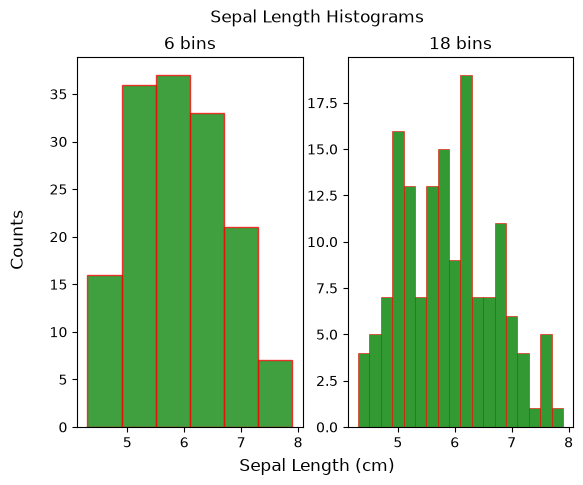

In [4]:
# Your histogram code here
sepal_length = iris["sepal.length"]

fig, axes = plt.subplots(1,2)

#6 bin histogram
axes[0].hist(sepal_length, bins=6, color = "green", edgecolor = "red", alpha = 0.75) #aplha sets transparency
axes[0].set_title("6 bins")

#18 bin histogram
axes[1].hist(sepal_length,bins=18, color = "green", edgecolor = "red", alpha = 0.8, linewidth = "0.5")
axes[1].set_title("18 bins")

#Overall titles (applying to both subplots)
fig.suptitle("Sepal Length Histograms")
fig.supylabel("Counts")
fig.supxlabel("Sepal Length (cm)")

**Answer:**

*#1*
Both the 6 and 18 bin histogram have a roughly symmetric shape.

*#2*
Changing the number of bins reveals a much less continuous distribution of the data: the 6 bin histogram makes the data appear evenly spread out, whereas the 18 bin histogram shows that the distribution has sections of the data with higher concentrations/counts than others. The section with the highest counts is also different. In the 6 bin histogram, is in the 5.5-6.1 range, whereas in the 18 bin histogram, it is in the 6.1-6.3 range. 

### B. Grouped numerical summary (1 pt)

Calculate the `count`, `median`, sample `std`, `min`, and `max` of `sepal.length` for each Iris species using `groupby()` and `agg()`.

Which species has the largest median `sepal.length`? Which has the largest sample standard deviation?


In [5]:
# Useful pattern:
# iris.groupby("variety")["sepal.length"].agg([...])

# Your code here
summary_data = iris.groupby("variety")["sepal.length"].agg(["count","median","std","min","max"])
summary_data #display

,count,median,std,min,max
variety,,,,,
Setosa,50,5.0,0.352490,4.3,5.8
Versicolor,50,5.9,0.516171,4.9,7.0
Virginica,50,6.5,0.635880,4.9,7.9


**Answer:** Virginica is the species with the largest median sepal length. Virginica is also the species that has the largest sample standard deviation.


### C. Boxplot by species (1.5 pts)

Create a boxplot of `sepal.length` grouped by `variety`.

Give the plot a clear title and axis labels. Then state **two conclusions** supported by the boxplot: one about differences in center and one about differences in spread or overlap among the species.


Text(0.5, 0, 'Species of Iris')

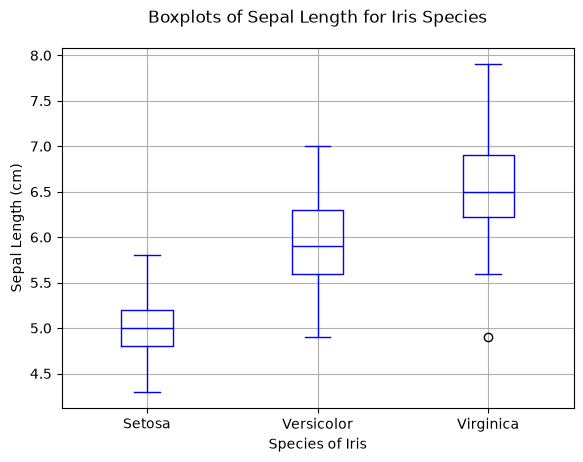

In [6]:
# Useful pattern:
# iris.boxplot(column="...", by="...")

# Your code here
ax = iris.boxplot(column="sepal.length", by = "variety", color = "blue")
ax.set_title("") #removing the sepal.length x axis label
plt.suptitle("Boxplots of Sepal Length for Iris Species") #overriding the auto-generated boxplot title
plt.ylabel("Sepal Length (cm)")
plt.xlabel("Species of Iris")



**Answer:** Based on the boxplots, Virginica irises have the highest median sepal length (6.5 cm), followed by Versicolor (~5.8 cm), and Setosa (5.0 cm) irises. All of the species' boxplots appear to be roughly symmetric, though the Virginica boxplot does display some signs of right-skewdness (longer whisker, greater distance between median and Q3 than median and Q1). The range of the Setosa irises' sepal lengths is smaller than Versicolor or Virginica irises, and the Virginica boxplot appears to have a slightly larger range than Versicolor irises. The Virginica boxplot is the only plot with an outlier, that being around 4.8 cm.


## LE2-4. Similar summaries can hide different distributions (2 pts)

The two datasets below have the same mean, median, and sample standard deviation, but their distributions are not the same.

### A. Compare numerical summaries (0.75 pt)

For datasets A and B, calculate the:
- mean;
- median; and
- sample standard deviation.

Confirm that these three numerical summaries are the same (or equal to rounding).


In [7]:
comparison = pd.DataFrame(
    {
        "A": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "B": [0, 3, 4, 5, 5, 5, 6, 7, 10],
    }
)

comparison

# Useful pattern:
# comparison.agg(["mean", "median", "std"])

# Your code here
summary_A = comparison["A"].agg(["mean","median","std"])
summary_B = comparison["B"].agg(["mean","median","std"])

print("Summary A:\n",summary_A)
print("\nSummary B:\n",summary_B)

equality_boolean = (summary_A.tolist() == summary_B.tolist())
print("\n mean/median/std of A == mean/median/std of B: ", equality_boolean)


Summary A:
 mean      5.000000
median    5.000000
std       2.738613
Name: A, dtype: float64

Summary B:
 mean      5.000000
median    5.000000
std       2.738613
Name: B, dtype: float64

 mean/median/std of A == mean/median/std of B:  True


### B. Visualize the distributions (0.75 pt)

Choose **one** of the following ways to compare datasets A and B:
- histograms using the same bins and x-axis scale; or
- boxplots shown on the same figure.

Give the visualization a clear title and meaningful axis labels.


Text(0.02, 0.5, 'Value')

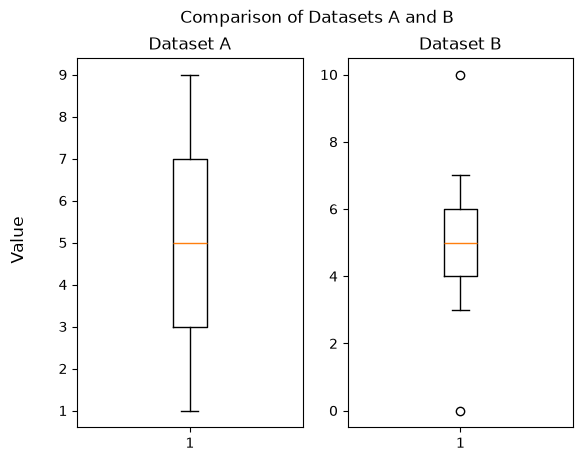

In [8]:
# Your visualization code here

fig, axes = plt.subplots(1,2)

#Dataset A
axes[0].boxplot(comparison["A"])
axes[0].set_title("Dataset A")

#Dataset B
axes[1].boxplot(comparison["B"])
axes[1].set_title("Dataset B")

fig.suptitle("Comparison of Datasets A and B")
fig.supylabel("Value")

### C. Interpret (0.5 pt)

What important difference between datasets A and B is visible in your plot but hidden by the mean, median, and sample standard deviation?

In one or two sentences, explain why numerical summaries and visualizations should be used together.

**Answer:** Despite having the same mean, meadian, and standard deviation, visualizing both datasets using boxplots reveals that dataset A is more evenly distributed than dataset B. Dataset B has a much smaller IQR than dataset A, but it also has one high and one low outlier present. By simply looking at numerical summary data, these differences would not have been noticed, so in general, numerical summaries don't reveal everything about a dataset, which is why data visualization is important (Anscombe's Lesson).


## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA2",
  "export_n": 1,
  "session_date": "2026-09-13",
  "messages": [
    {"i": 1, "who": "student", "text": "Can you provide me of how to make a table using a pandas dataframe?"},
    {"i": 2, "who": "tutor", "text": "Explained three ways to build a pandas DataFrame: from a dictionary of lists, from a list of row-dictionaries, and from lists of columns directly, with generic examples and useful attributes (df.columns, df.head(), df.shape). Ended by asking if this was for the assignment or general curiosity."},
    {"i": 3, "who": "student", "text": "How can I adjust the index titles?"},
    {"i": 4, "who": "tutor", "text": "Explained renaming columns (df.rename(columns=...), df.columns = [...]), renaming row index labels (df.rename(index=...), df.set_index()), and naming the index axis itself (df.index.name). Noted rename() returns a new DataFrame by default. Asked if this was for tidying a table being built."},
    {"i": 5, "who": "student", "text": "If I wanted text on both sides of the table, how could I rename the row titles from 0, 1, 2 to a string variable?"},
    {"i": 6, "who": "tutor", "text": "Explained assigning a list directly to df.index (positional replacement, must match row count), including an example building row_names from a loop over some_series.unique(). Also covered df.rename(index={...}) for partial renames and df.set_index('category') for using an existing column. Warned that direct index assignment doesn't validate correspondence to rows. Offered to show df.index.name combined with this."},
    {"i": 7, "who": "student", "text": "Is there a way I can include the row names in the initial dataframe creation?"},
    {"i": 8, "who": "tutor", "text": "Explained passing index= as a constructor argument, with examples from a dictionary of columns and from a list of lists with columns= and index= together, and using a variable for row_names. Noted index= only sets row labels, not the axis name (still needs df.index.name separately). Offered to show combining with column naming at construction time."},
    {"i": 9, "who": "student", "text": "Is it possible to give the data frame a title in the top left?"},
    {"i": 10, "who": "tutor", "text": "Explained df.index.name for the axis label near the top-left corner, df.rename_axis(index=..., columns=...) for naming both axes at once, and df.style.set_caption() for an actual table caption (noting .style returns a Styler, not a DataFrame). Noted pandas has no dedicated top-left corner cell to write arbitrary text into. Asked if this was for polishing an assignment table."},
    {"i": 11, "who": "student", "text": "Thanks"},
    {"i": 12, "who": "tutor", "text": "Acknowledged thanks and invited the student back if they hit snags building the actual assignment tables."},
    {"i": 13, "who": "student", "text": "Is it possible to perform this sort of calculation to identifiy outliers, or must I perform this command twice with the upper and lower bounds? \n\n```python\nflagged_values = sepal_width[sepal_width < lower_sw_filter or sepal_width > upper_sw_filter]\n\n```", "code": true},
    {"i": 14, "who": "tutor", "text": "Explained that Python's `or` doesn't work element-wise on Series/arrays and would raise a ValueError. Showed the fix using bitwise `|` with parentheses around each condition, explained why parentheses are needed (operator precedence), and gave a quick reference for `&`, `|`, `~` versus plain `and`, `or`, `not`. Confirmed one line can handle both bounds."},
    {"i": 15, "who": "student", "text": "Is there a way I can convert the output data to an easily printable data structure?"},
    {"i": 16, "who": "tutor", "text": "Explained several conversion options on generic example: .tolist() for a plain list, .to_string() for a clean multi-line block, .to_numpy() for an array, .describe() for a summary, and reset_index() to turn a Series into a two-column DataFrame. Asked which format matched what the student wanted."},
    {"i": 17, "who": "student", "text": "make my record"}
  ],
  "events": [],
  "parts": [],
  "tutor_assessment": [
    "The student asked no assignment-specific questions this session — all questions were general pandas/Python technique (DataFrame construction, renaming indices, boolean masking with | vs or, converting Series to printable structures), so no assignment step was attempted or blocked on.",
    "No use of the release valve or 'I got it, let's move on' occurred; nothing suggests a tutoring failure this session."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA2",
  "export_n": 2,
  "session_date": "2026-09-13",
  "messages": [
    {"i": 1, "who": "student", "text": "Can you provide me of how to make a table using a pandas dataframe?"},
    {"i": 2, "who": "tutor", "text": "Explained three ways to build a pandas DataFrame: from a dictionary of lists, from a list of row-dictionaries, and from lists of columns directly, with generic examples and useful attributes (df.columns, df.head(), df.shape). Ended by asking if this was for the assignment or general curiosity."},
    {"i": 3, "who": "student", "text": "How can I adjust the index titles?"},
    {"i": 4, "who": "tutor", "text": "Explained renaming columns (df.rename(columns=...), df.columns = [...]), renaming row index labels (df.rename(index=...), df.set_index()), and naming the index axis itself (df.index.name). Noted rename() returns a new DataFrame by default. Asked if this was for tidying a table being built."},
    {"i": 5, "who": "student", "text": "If I wanted text on both sides of the table, how could I rename the row titles from 0, 1, 2 to a string variable?"},
    {"i": 6, "who": "tutor", "text": "Explained assigning a list directly to df.index (positional replacement, must match row count), including an example building row_names from a loop over some_series.unique(). Also covered df.rename(index={...}) for partial renames and df.set_index('category') for using an existing column. Warned that direct index assignment doesn't validate correspondence to rows. Offered to show df.index.name combined with this."},
    {"i": 7, "who": "student", "text": "Is there a way I can include the row names in the initial dataframe creation?"},
    {"i": 8, "who": "tutor", "text": "Explained passing index= as a constructor argument, with examples from a dictionary of columns and from a list of lists with columns= and index= together, and using a variable for row_names. Noted index= only sets row labels, not the axis name. Offered to show combining with column naming at construction time."},
    {"i": 9, "who": "student", "text": "Is it possible to give the data frame a title in the top left?"},
    {"i": 10, "who": "tutor", "text": "Explained df.index.name for the axis label near the top-left corner, df.rename_axis(index=..., columns=...) for naming both axes at once, and df.style.set_caption() for an actual table caption. Noted pandas has no dedicated top-left corner cell to write arbitrary text into. Asked if this was for polishing an assignment table."},
    {"i": 11, "who": "student", "text": "Thanks"},
    {"i": 12, "who": "tutor", "text": "Acknowledged thanks and invited the student back if they hit snags building the actual assignment tables."},
    {"i": 13, "who": "student", "text": "Is it possible to perform this sort of calculation to identifiy outliers, or must I perform this command twice with the upper and lower bounds? \n\n```python\nflagged_values = sepal_width[sepal_width < lower_sw_filter or sepal_width > upper_sw_filter]\n\n```", "code": true},
    {"i": 14, "who": "tutor", "text": "Explained that Python's `or` doesn't work element-wise on Series/arrays and would raise a ValueError. Showed the fix using bitwise `|` with parentheses around each condition, explained operator precedence, and gave a quick reference for `&`, `|`, `~` versus plain `and`, `or`, `not`. Confirmed one line can handle both bounds."},
    {"i": 15, "who": "student", "text": "Is there a way I can convert the output data to an easily printable data structure?"},
    {"i": 16, "who": "tutor", "text": "Explained conversion options on a generic example: .tolist(), .to_string(), .to_numpy(), .describe(), and reset_index() to turn a Series into a two-column DataFrame. Asked which format matched what the student wanted."},
    {"i": 17, "who": "student", "text": "make my record"},
    {"i": 18, "who": "tutor", "text": "[first export produced; export_n=1]"},
    {"i": 19, "who": "student", "text": "Can you give me a few examples of how to make subplots (ex. 1 by 2) in matplotlib"},
    {"i": 20, "who": "tutor", "text": "Gave generic matplotlib examples: 1x2 grid with plt.subplots(1,2), indexing axes[0]/axes[1], figsize, tight_layout, a 2x2 grid with axes[row,col], sharey/sharex, and looping over axes with zip(axes, datasets). Asked if this related to visualizing assignment results."},
    {"i": 21, "who": "student", "text": "The .plt.hist comannd is no longer working, is there a way I can get around that?"},
    {"i": 22, "who": "tutor", "text": "Asked for the exact line and error/traceback before diagnosing, noting the odd '.plt.hist' syntax and the difference between plt.hist() and ax.hist()."},
    {"i": 23, "who": "student", "text": "I am getting an attribute error"},
    {"i": 24, "who": "tutor", "text": "Asked for the exact line of code and full error text to identify which object lacked the attribute."},
    {"i": 25, "who": "student", "text": "```python\naxes = plt.subplots(1,2)\n\naxes[0].plot.hist(sepal_length,bins=6)\n```", "code": true},
    {"i": 26, "who": "tutor", "text": "Identified two issues: plt.subplots() returns (fig, axes) as a tuple, so unpacking only into axes makes axes[0] the figure, not an axis; fixed with fig, axes = plt.subplots(1,2). Also explained .plot.hist() is a pandas pattern, not a matplotlib-axis pattern; the correct call is axes[0].hist(sepal_length, bins=6). Gave the corrected combined code and asked the student to try it."},
    {"i": 27, "who": "student", "text": "How can I label subplots?"},
    {"i": 28, "who": "tutor", "text": "Explained set_title/set_xlabel/set_ylabel per axis, fig.suptitle() for the whole figure, labeling with letters like (a)/(b), and looping over axes with zip(axes, titles). Warned about calling suptitle on the wrong object causing an AttributeError. Offered to show with tight_layout."},
    {"i": 29, "who": "student", "text": "Is there a way I can title the overall subplot and also have subtitles for each individual subplot?"},
    {"i": 30, "who": "tutor", "text": "Combined fig.suptitle() with per-axis set_title() in one example, and noted suptitle/tight_layout can overlap, suggesting fig.suptitle(..., y=1.05) to nudge it up. Asked the student to check spacing."},
    {"i": 31, "who": "student", "text": "Can I also set x and y labels for the full subplot?"},
    {"i": 32, "who": "tutor", "text": "Explained fig.supxlabel()/fig.supylabel() for shared labels, noted these require a fairly recent matplotlib version, and offered alternatives: labeling only outer subplots manually, or using sharey/sharex with a single label on the shared edge."},
    {"i": 33, "who": "student", "text": "Is there a way I can add more visual definition between the bins of a histogram?"},
    {"i": 34, "who": "tutor", "text": "Explained edgecolor and linewidth arguments to .hist(), plus alpha for transparency, color for bin fill, and ax.grid(axis='y', alpha=0.3) for a light background grid. Recommended edgecolor='black' with linewidth ~1-1.5 as the common fix."},
    {"i": 35, "who": "student", "text": "Can you demonstrate how to use .agg()"},
    {"i": 36, "who": "tutor", "text": "Demonstrated .agg() on a plain Series (single and multiple aggregations), then combined with groupby: basic groupby().agg([...]), naming output columns via keyword arguments, and applying different aggregations to different columns with a dict. Noted groupby().agg() is often an alternative to a for loop over groups, and offered to discuss when a loop is required."},
    {"i": 37, "who": "student", "text": "How can I fix this command to avoid getting a TypeError?"},
    {"i": 38, "who": "tutor", "text": "Asked for the exact line and full error text before diagnosing TypeErrors, since many different causes are possible."},
    {"i": 39, "who": "student", "text": "```python\nsummary_data = iris.groupby(\"sepal.length\").agg([\"count\",\"median\",\"std\",\"min\",\"max\"])\n```", "code": true},
    {"i": 40, "who": "tutor", "text": "Still asked for the full traceback, but flagged that calling .agg([...]) on the whole grouped DataFrame without selecting a column applies the functions to every column including non-numeric ones, which commonly causes a TypeError. Asked whether iris has a categorical/species column."},
    {"i": 41, "who": "student", "text": "TypeError                                 Traceback (most recent call last) Cell In[87], [line 5](vscode-notebook-cell:?execution_count=87&line=5)       1 # Useful pattern:       2 # iris.groupby(\"variety\")[\"sepal.length\"].agg([...])       3        4 # Your code here ----> [5](vscode-notebook-cell:?execution_count=87&line=5) summary_data = iris.groupby(\"sepal.length\").agg([\"median\",\"std\",\"min\",\"max\"])  File ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\groupby\\generic.py:2291, in DataFrameGroupBy.aggregate(self, func, engine, engine_kwargs, *args, **kwargs)    2288     kwargs[\"engine_kwargs\"] = engine_kwargs    2290 op = GroupByApply(self, func, args=args, kwargs=kwargs) -> [2291](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE02/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/groupby/generic.py:2291) result = op.agg()    2292 if not is_dict_like(func) and result is not None:    2293     # GH #52849    2294     if not self.as_index and is_list_like(func):  File ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\apply.py:297, in Apply.agg(self)     294     return self.agg_dict_like()     295 elif is_list_like(func):     296     # we require a list, but not a 'str' --> [297](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE02/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/apply.py:297)     return self.agg_list_like()     299 # caller can react     300 return None \n...\n   2811     if op.how not in [\"any\", \"all\"]:    2812         # Fail early to avoid conversion to object    2813         op._get_cython_function(op.kind, op.how, np.dtype(object), False)  TypeError: dtype 'str' does not support operation 'median'"},
    {"i": 42, "who": "tutor", "text": "Confirmed the traceback matched the diagnosis: median/std/min/max can't run on a text column. Suggested selecting the numeric column before aggregating: iris.groupby(\"variety\")[\"sepal.length\"].agg([...]). Also flagged that grouping by 'sepal.length' itself (the column being summarized) would give near-single-row groups, and asked whether 'variety' was the intended groupby column."},
    {"i": 43, "who": "student", "text": "Why must (\"variety\") be included if only the sepal.length column is being analayzed?"},
    {"i": 44, "who": "tutor", "text": "Explained that groupby(\"variety\") determines how rows are bucketed while [\"sepal.length\"] determines which column's values get summarized within those buckets — two independent jobs. Illustrated what happens if only one or the other is used, and offered a made-up-data example if helpful."},
    {"i": 45, "who": "student", "text": "I see, thank you"},
    {"i": 46, "who": "tutor", "text": "Acknowledged and offered to continue with the assignment or other questions."},
    {"i": 47, "who": "student", "text": "How can I feed in the sample standard deviation command into the .agg() command"},
    {"i": 48, "who": "tutor", "text": "Explained that .agg() accepts custom functions/lambdas, showed lambda x: x.std(ddof=1) inside agg(), naming that column via keyword argument, mixing it with string-named aggregations, and using np.std(x, ddof=1) as an alternative. Noted pandas' .std() already defaults to ddof=1, so the lambda mainly matters for ddof=0 or explicitness."},
    {"i": 49, "who": "student", "text": "What commands can I use to add titles to a pandas boxplot?"},
    {"i": 50, "who": "tutor", "text": "Explained titling with df.boxplot() plus plt.title()/plt.suptitle(), using an ax from plt.subplots() with ax.set_title(), and multiple boxplot subplots with fig.suptitle(). Noted pandas' by= can auto-generate a title that may overlap with a manual one."},
    {"i": 51, "who": "student", "text": "Is there a way I can override the default title created by pandas?"},
    {"i": 52, "who": "tutor", "text": "Explained overriding pandas' auto-generated title by calling plt.suptitle() again afterward, clearing an individual axis title with ax.set_title(\"\") if needed, and the ax-based pattern for overwriting without stacking. Noted set_title/suptitle replace rather than append, and that which one pandas used may take some trial and error. Asked the student to try it and report what they see."},
    {"i": 53, "who": "student", "text": "make my record"}
  ],
  "events": [],
  "parts": [],
  "tutor_assessment": [
    "As with the first export in this conversation, the student asked only general Python/pandas/matplotlib technique questions this session (DataFrames, index/title formatting, boolean masking, subplots, histogram styling, .agg(), boxplot titling) plus one real debugging exchange (a genuine AttributeError and TypeError from the student's own code, both resolved with the evidence-first protocol). No assignment-specific step from LE2-1, LE2-2, or LE2-3 was attempted.",
    "No use of the release valve or 'I got it, let's move on' occurred; nothing suggests a tutoring failure this session."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
